In [1]:
import datetime
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import yfinance as yfin
from datetime import date

pd.options.display.float_format="{:,.6f}".format

In [2]:
start = datetime.date(2019,3,25)
end = datetime.date(2026,3,25)

In [3]:
df_bc = yfin.download(['BTC-USD'], start=start, end=end, auto_adjust=False)['Adj Close']
df_bc.index = df_bc.index.tz_localize('UTC')
df_bc.head()

[*********************100%***********************]  1 of 1 completed


Ticker,BTC-USD
Date,
2019-03-25 00:00:00+00:00,"3,963.070557"
2019-03-26 00:00:00+00:00,"3,985.080811"
2019-03-27 00:00:00+00:00,"4,087.066162"
2019-03-28 00:00:00+00:00,"4,069.107178"
2019-03-29 00:00:00+00:00,"4,098.374512"


In [4]:
df_bc.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2558 entries, 2019-03-25 00:00:00+00:00 to 2026-03-25 00:00:00+00:00
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   BTC-USD  2557 non-null   float64
dtypes: float64(1)
memory usage: 40.0 KB


In [5]:
url1="https://raw.githubusercontent.com/Sahdam/Nigerian-Financial-Risk-Intelligence-System/refs/heads/main/Zenith%20Bank%20Stock%20Price%20History.csv"
df_z = pd.read_csv(url1, parse_dates=['Date'], index_col='Date')['Price']
df_z.index = df_z.index.tz_localize('UTC')
df_z.rename('ZENITHBANK', inplace=True)
df_z = df_z.sort_index(ascending=True)
df_z.head()

,ZENITHBANK
Date,
2019-03-25 00:00:00+00:00,21.500000
2019-03-26 00:00:00+00:00,21.700000
2019-03-27 00:00:00+00:00,22.000000
2019-03-28 00:00:00+00:00,21.800000
2019-03-29 00:00:00+00:00,21.800000


In [6]:
print(df_z.info())
print(" \n")
print(df_bc.info())


<class 'pandas.core.series.Series'>
DatetimeIndex: 1733 entries, 2019-03-25 00:00:00+00:00 to 2026-03-25 00:00:00+00:00
Series name: ZENITHBANK
Non-Null Count  Dtype  
--------------  -----  
1733 non-null   float64
dtypes: float64(1)
memory usage: 27.1 KB
None
 

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2558 entries, 2019-03-25 00:00:00+00:00 to 2026-03-25 00:00:00+00:00
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   BTC-USD  2557 non-null   float64
dtypes: float64(1)
memory usage: 40.0 KB
None


In [7]:
df = df_bc.merge(df_z, left_index=True, right_index=True, how='outer')

print(df.shape)
print("\n")
print(df.head(10))

(2558, 2)


                               BTC-USD  ZENITHBANK
Date                                              
2019-03-25 00:00:00+00:00 3,963.070557   21.500000
2019-03-26 00:00:00+00:00 3,985.080811   21.700000
2019-03-27 00:00:00+00:00 4,087.066162   22.000000
2019-03-28 00:00:00+00:00 4,069.107178   21.800000
2019-03-29 00:00:00+00:00 4,098.374512   21.800000
2019-03-30 00:00:00+00:00 4,106.660156         NaN
2019-03-31 00:00:00+00:00 4,105.404297         NaN
2019-04-01 00:00:00+00:00 4,158.183105   21.900000
2019-04-02 00:00:00+00:00 4,879.877930   21.300000
2019-04-03 00:00:00+00:00 4,973.021973   20.400000


In [8]:
df_test = df.copy()
df_test.head()

,BTC-USD,ZENITHBANK
Date,,
2019-03-25 00:00:00+00:00,"3,963.070557",21.500000
2019-03-26 00:00:00+00:00,"3,985.080811",21.700000
2019-03-27 00:00:00+00:00,"4,087.066162",22.000000
2019-03-28 00:00:00+00:00,"4,069.107178",21.800000
2019-03-29 00:00:00+00:00,"4,098.374512",21.800000


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2558 entries, 2019-03-25 00:00:00+00:00 to 2026-03-25 00:00:00+00:00
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   BTC-USD     2557 non-null   float64
 1   ZENITHBANK  1733 non-null   float64
dtypes: float64(2)
memory usage: 60.0 KB


In [10]:
df.describe()

,BTC-USD,ZENITHBANK
count,"2,557.000000","1,733.000000"
mean,"43,898.502923",32.109019
std,"32,162.238074",16.600227
min,"3,963.070557",10.700000
25%,"16,848.126953",21.300000
50%,"36,575.140625",25.000000
75%,"64,096.199219",37.600000
max,"124,752.531250",111.150000


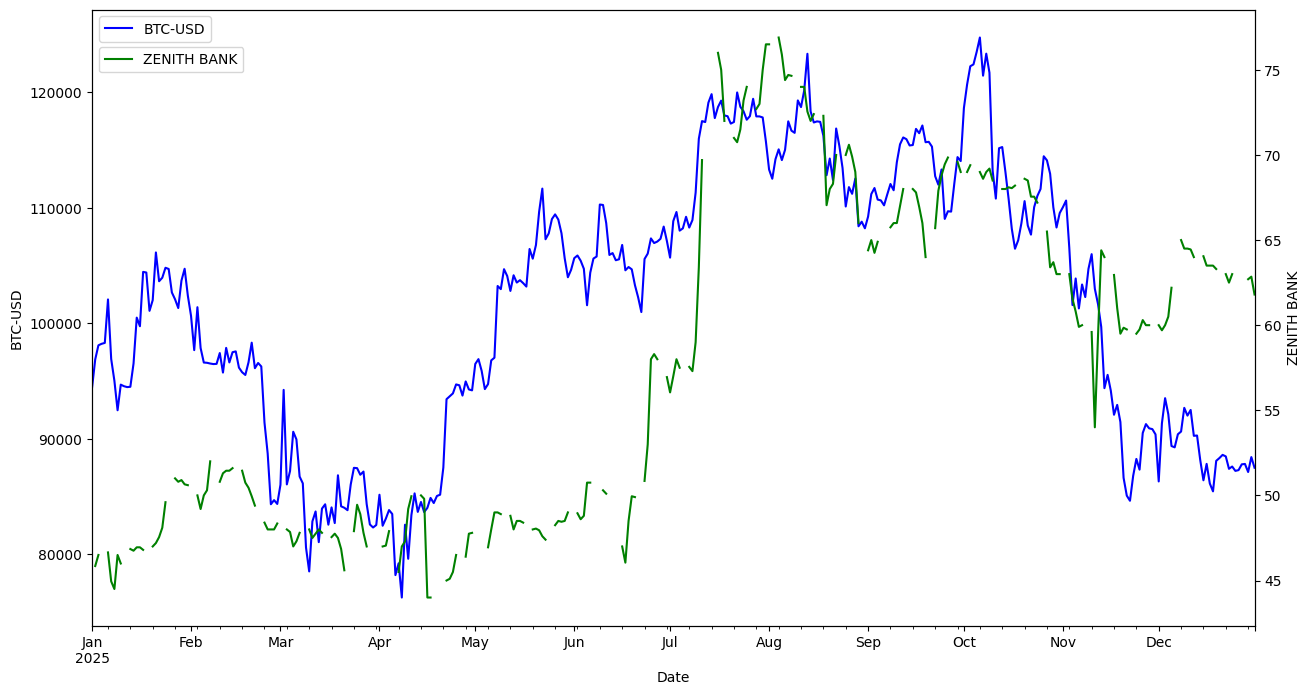

In [11]:
from matplotlib import legend
fig = plt.figure(figsize=(15,8))
ax1 = fig.add_subplot(111)
ax2 = ax1.twinx()

df['2025-01-01': '2025-12-31'].plot(ax=ax1, y='BTC-USD', color='blue', label='BTC-USD', legend=True)
df['2025-01-01': '2025-12-31'].plot(ax=ax2, y="ZENITHBANK", color="green", label ='ZENITH BANK', legend=True)

ax1.set_ylabel('BTC-USD')
ax2.set_ylabel('ZENITH BANK')

ax1.legend(['BTC-USD'], loc='upper left')
ax2.legend(['ZENITH BANK'], loc='upper left',  bbox_to_anchor=(0, 0.95))

plt.show()

In [12]:
df_return = np.log(df / df.shift(1)).dropna()
df_return.head(10)

,BTC-USD,ZENITHBANK
Date,,
2019-03-26 00:00:00+00:00,0.005538,0.009259
2019-03-27 00:00:00+00:00,0.025270,0.013730
2019-03-28 00:00:00+00:00,-0.004404,-0.009132
2019-03-29 00:00:00+00:00,0.007167,0.000000
2019-04-02 00:00:00+00:00,0.160042,-0.027780
2019-04-03 00:00:00+00:00,0.018907,-0.043172
2019-04-04 00:00:00+00:00,-0.010150,0.004890
2019-04-05 00:00:00+00:00,0.022870,-0.007344
2019-04-09 00:00:00+00:00,-0.016163,-0.002478


In [13]:
avg_annual_return = df_return.mean() * 252
avg_annual_return

,0
BTC-USD,0.226665
ZENITHBANK,0.247177


In [14]:
avg_daily_return = df_return.mean()
avg_daily_return

,0
BTC-USD,0.000899
ZENITHBANK,0.000981


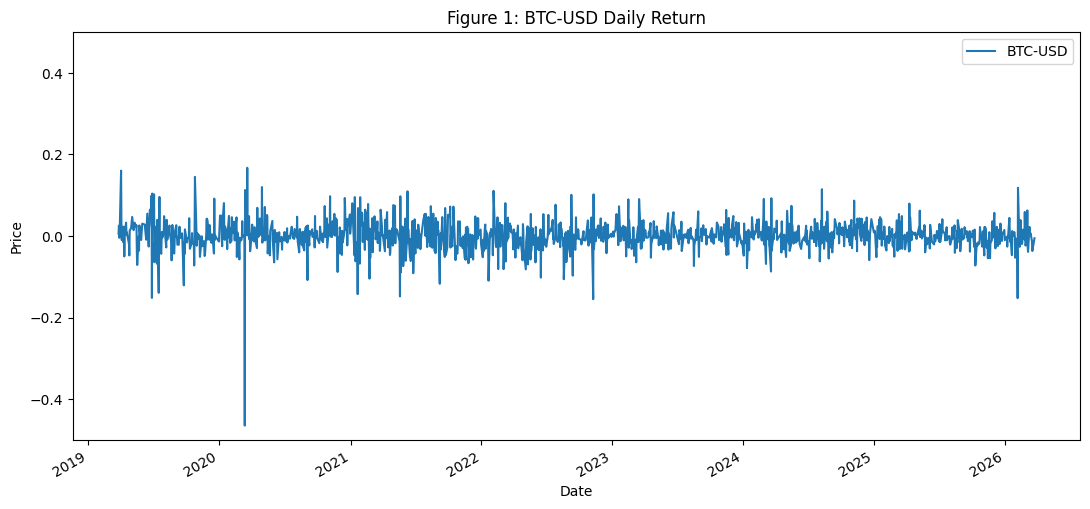

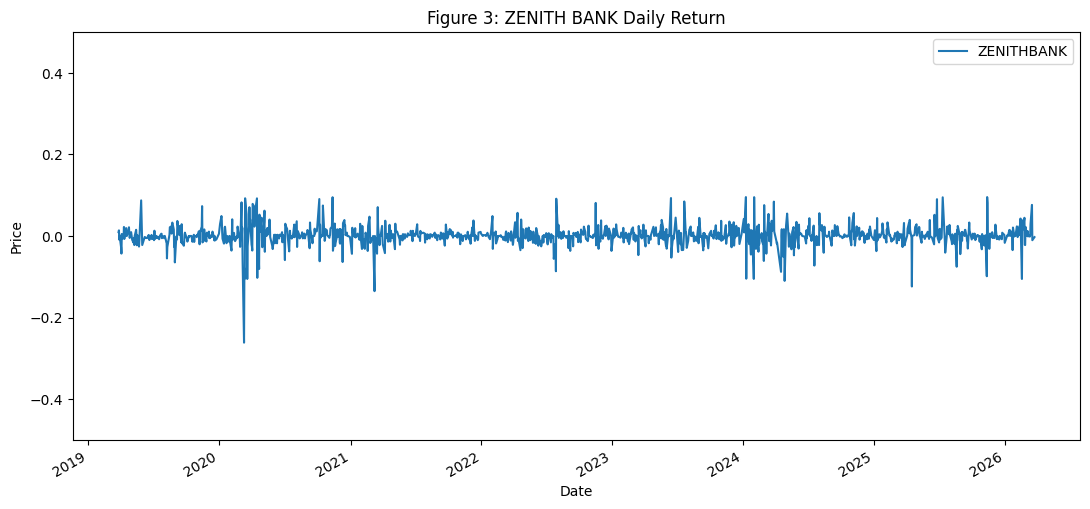

In [15]:
ax1 = df_return.plot(figsize=(13,6), y='BTC-USD', title='Figure 1: BTC-USD Daily Return')
ax2 = df_return.plot(figsize=(13,6), y='ZENITHBANK', title='Figure 3: ZENITH BANK Daily Return')

ax1.set_ylabel('Price')
ax1.set_xlabel('Date')
ax2.set_ylabel('Price')
ax2.set_xlabel('Date')


ax1.set_ylim(-0.5, 0.5)
ax2.set_ylim(-0.5, 0.5)

plt.show()

In [17]:
df.tail()

,BTC-USD,ZENITHBANK
Date,,
2026-03-21 00:00:00+00:00,"68,711.523438",NaN
2026-03-22 00:00:00+00:00,"67,845.210938",NaN
2026-03-23 00:00:00+00:00,"70,914.859375",107.500000
2026-03-24 00:00:00+00:00,"70,517.859375",107.200000
2026-03-25 00:00:00+00:00,NaN,106.850000


In [21]:
#High_low Volatility BTC

end = pd.Timestamp(df.index[-2])
curr_year = df.loc[end - pd.Timedelta(days=365) : end]

(curr_year.max() - curr_year.min())/df.iloc[-2]

,0
BTC-USD,0.879925
ZENITHBANK,0.626399


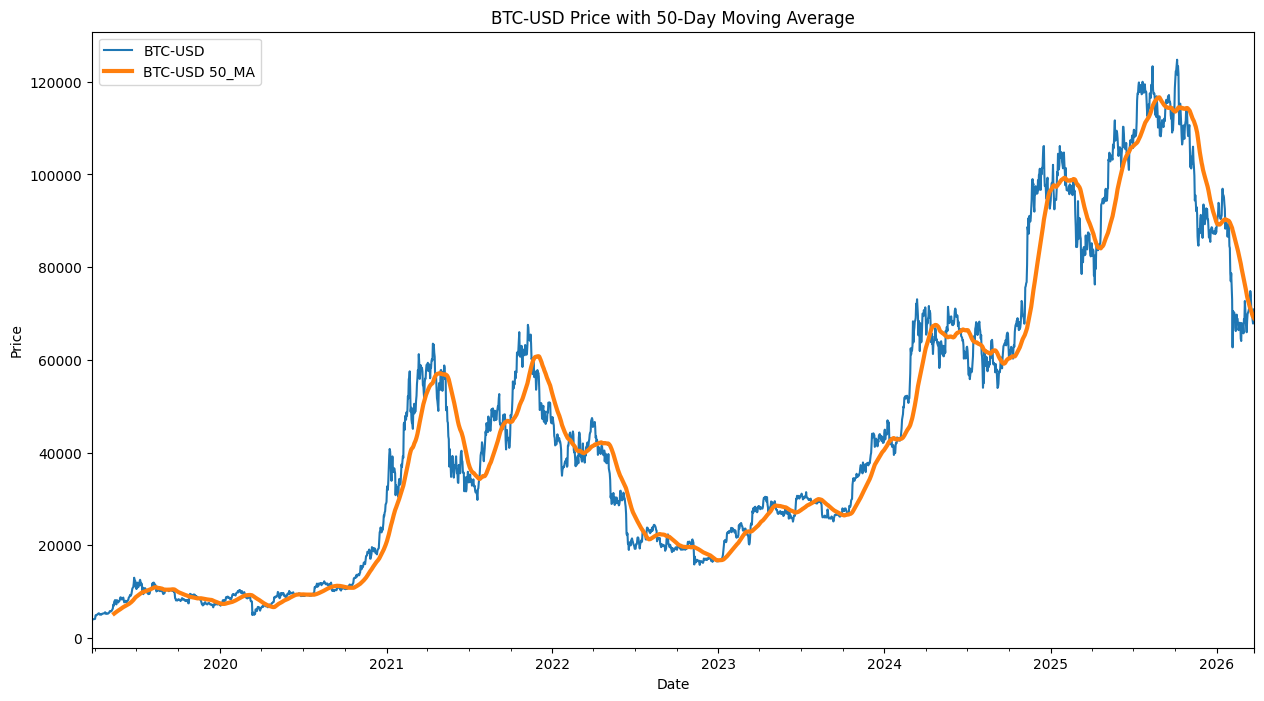

In [22]:
#Moving Average BTC

df['BTC-USD 50_MA'] = df['BTC-USD'].rolling(window=50).mean()

plt.figure(figsize=(15,8))
df["BTC-USD"].plot(label="BTC-USD")
df['BTC-USD 50_MA'].plot(label="BTC-USD 50_MA", linewidth=3)
plt.legend()
plt.title('BTC-USD Price with 50-Day Moving Average')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

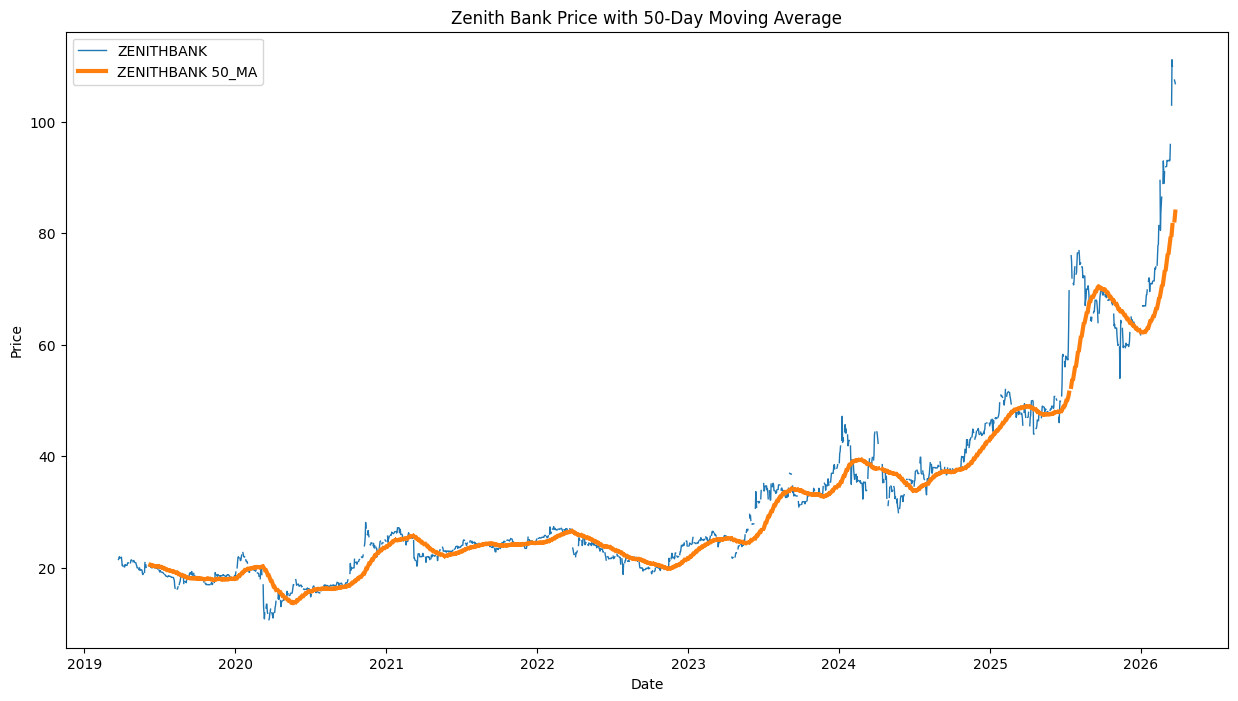

In [24]:
# Moving Avg ZENITH
df['ZENITHBANK 50_MA'] = df['ZENITHBANK'].dropna().rolling(window=50).mean()

plt.figure(figsize=(15, 8))

# Plot both explicitly with matplotlib
plt.plot(df.index, df['ZENITHBANK'], label='ZENITHBANK', linewidth=1)
plt.plot(df.index, df['ZENITHBANK 50_MA'], label='ZENITHBANK 50_MA',
         linewidth=3)

plt.legend()
plt.title('Zenith Bank Price with 50-Day Moving Average')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

In [25]:
# Rolling distance

(abs(df - df.dropna().rolling(window=50).mean())/df).mean()

,0
BTC-USD,0.129823
ZENITHBANK,0.069026
BTC-USD 50_MA,0.110189
ZENITHBANK 50_MA,0.050001


In [26]:
# Standard Deviations

df_return.std()

,0
BTC-USD,0.036267
ZENITHBANK,0.024185


In [27]:
def InvestmentComparison(startTime, endTime, df):
  startTime = pd.Timestamp(startTime).tz_localize('UTC')
  endTime = pd.Timestamp(endTime).tz_localize('UTC')

  returns = np.log(df)-np.log(df.shift(1))
  returns = returns.iloc[1:, 0:]

  curr_year= df.loc[endTime - pd.Timedelta(days=365) : endTime]


  highlow_series = (curr_year.max() - curr_year.min()) / df.iloc[-2]


  # Calculate MA as a Series, considering only original asset columns
  ma_series = (abs(df - df.dropna().rolling(window=50).mean())/df).mean()

  # Calculate std as a Series
  std_series = returns.std()

  # Calculate daily return as a Series
  daily_return_series = returns.mean()

  # Combine all Series into a single DataFrame
  investment = pd.DataFrame({
      'highlow': highlow_series,
      'MA': ma_series,
      'std': std_series,
      'daily return': daily_return_series
  })

  # Format the columns
  investment['highlow'] = investment['highlow'].round(4).astype(str)

  # Format other columns as percentages
  for col_name in ["std", "daily return", 'MA']:
    investment[col_name] = (investment[col_name]*100).round(3).astype(str) + '%'

  return investment

In [29]:
InvestmentComparison('2020-01-01', '2026-01-01', df_test)

,highlow,MA,std,daily return
BTC-USD,0.6875,13.123%,3.305%,0.113%
ZENITHBANK,0.3069,6.867%,2.418%,0.098%


In [30]:
InvestmentComparison('2024-01-01', '2025-01-01', df_test)

,highlow,MA,std,daily return
BTC-USD,0.9449,13.123%,3.305%,0.113%
ZENITHBANK,0.1613,6.867%,2.418%,0.098%


In [31]:
# Covariance

df_return.cov()

,BTC-USD,ZENITHBANK
BTC-USD,0.001315,0.000019
ZENITHBANK,0.000019,0.000585


In [32]:
# Correlation

df_return.corr()

,BTC-USD,ZENITHBANK
BTC-USD,1.000000,0.021739
ZENITHBANK,0.021739,1.000000


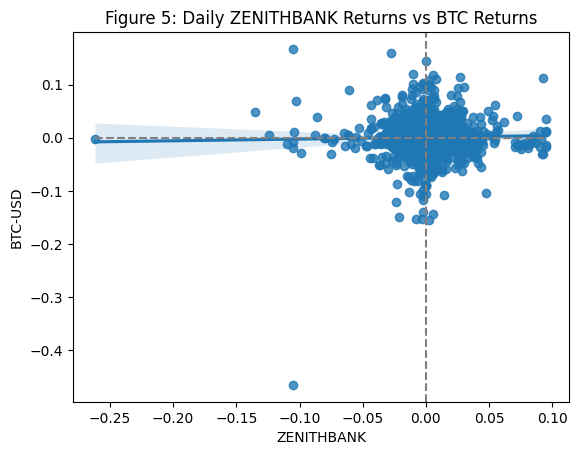

In [34]:
# Create scatter plot with regression line
chart3 = sns.regplot(x="ZENITHBANK", y="BTC-USD", data=df_return).set(
    title="Figure 5: Daily ZENITHBANK Returns vs BTC Returns"
)

# Add vertical line at x=0 and horizontal line at y=0
plt.axvline(0, 0, 1, dash_capstyle="butt", linestyle="--", color="grey")
plt.plot([min(df_return['ZENITHBANK']), max(df_return['ZENITHBANK'])], [0, 0], linestyle="--", color="grey");

In [35]:
# sharpe ratio

sharpe_ratio = np.sqrt(252) * (df_return.mean() / df_return.std())
sharpe_ratio

,0
BTC-USD,0.393702
ZENITHBANK,0.643813


In [36]:
# Semivariance

mean_returns = df_return.mean()
semivariance = (df_return[df_return < mean_returns] - mean_returns)**2
semi_var = semivariance.mean()

semi_var

,0
BTC-USD,0.001387
ZENITHBANK,0.000568


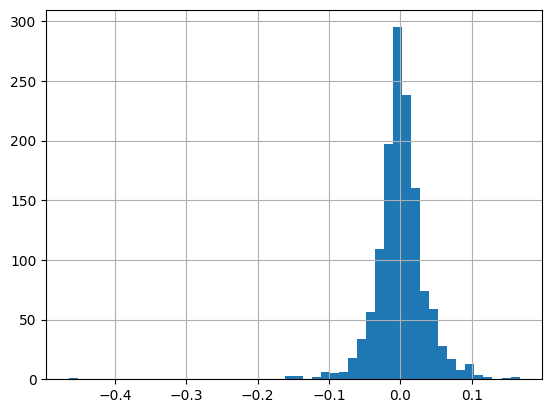

In [37]:
df_return['BTC-USD'].hist(bins=50);

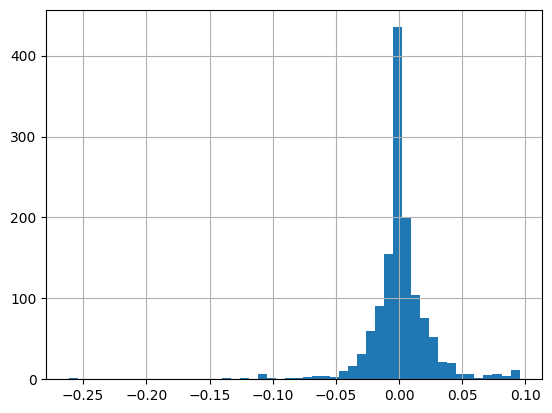

In [38]:
df_return["ZENITHBANK"].hist(bins=50);

In [39]:
from scipy import stats

In [40]:
#D'Agostino and Pearson's normality test

stats.normaltest(df_return['BTC-USD'])

NormaltestResult(statistic=np.float64(654.8468082202365), pvalue=np.float64(6.336104757236754e-143))

In [41]:
stats.normaltest(df_return['ZENITHBANK'])

NormaltestResult(statistic=np.float64(487.4645571492264), pvalue=np.float64(1.4073961327591116e-106))

In [42]:
# Jacque bera

stats.jarque_bera(df_return['BTC-USD'])

SignificanceResult(statistic=np.float64(27920.657496135154), pvalue=np.float64(0.0))

In [43]:
stats.jarque_bera(df_return['ZENITHBANK'])

SignificanceResult(statistic=np.float64(13618.622939225963), pvalue=np.float64(0.0))

In [44]:
# minimum and maximum daily log returns
dfMax = df_return['ZENITHBANK'].max()
dfMin = df_return['ZENITHBANK'].min()

# Print maximum and minimum daily log returns
print("Maximum return of sample data is: ", round(dfMax, 5))
print("Minimum return of sample data is: ", round(dfMin, 5))
print(' - - - - - - - - - -')

# Calculates the number of standard deviations from the mean return
num_dev_max = (df_return['ZENITHBANK'].max() - df_return['ZENITHBANK'].mean()) / df_return['ZENITHBANK'].std()
num_dev_min = (df_return['ZENITHBANK'].min() - df_return['ZENITHBANK'].mean()) / df_return['ZENITHBANK'].std()

# Print num_dev_max and num_dev_min
print("Number of standard deviations from the mean for the maximum return: ", round(num_dev_max, 5))
print("Number of standard deviations from the mean for the minimum return: ", round(num_dev_min, 5))

Maximum return of sample data is:  0.09531
Minimum return of sample data is:  -0.26148
 - - - - - - - - - -
Number of standard deviations from the mean for the maximum return:  3.9003
Number of standard deviations from the mean for the minimum return:  -10.85213


In [45]:
stats.norm.cdf(-10.85213)

np.float64(9.74156552742683e-28)

In [46]:
# Calculates the upper and lowers bounds
upper = (3 * df_return['ZENITHBANK'].std()) + df_return['ZENITHBANK'].mean()
lower = (-3 * df_return['ZENITHBANK'].std()) + df_return['ZENITHBANK'].mean()

# Print the results
print("Upper bound: ", round(upper, 5))
print("Lower bound: ", round(lower, 5))

Upper bound:  0.07354
Lower bound:  -0.07157


In [47]:
# Calculates the number of data points
len(df_return[(df_return['ZENITHBANK'] < lower) | (df_return['ZENITHBANK'] > upper)])

39

Original rows: 1341
After removing zeros: 1158
count   1,158.000000
mean        0.001136
std         0.026024
min        -0.261480
25%        -0.008466
50%         0.001629
75%         0.010974
max         0.095310
Name: ZENITHBANK, dtype: float64

Fitted parameters: df=2.13, loc=0.000730, scale=0.012718


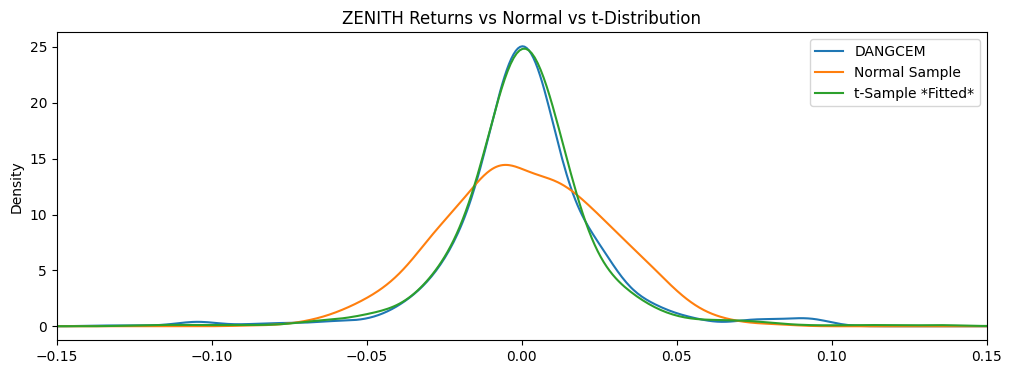

In [49]:
# Step 1: Remove zero returns before fitting
zenith_returns = df_return['ZENITHBANK']
zenith_clean = zenith_returns[zenith_returns != 0].dropna()

print(f"Original rows: {len(zenith_returns)}")
print(f"After removing zeros: {len(zenith_clean)}")
print(zenith_clean.describe())

# Step 2: Fit t-distribution to cleaned returns
params = stats.t.fit(zenith_clean)
print(f"\nFitted parameters: df={params[0]:.2f}, loc={params[1]:.6f}, scale={params[2]:.6f}")

# Step 3: Generate fitted samples
fitted_samples = stats.t.rvs(*params, size=len(zenith_clean))

# Step 4: Normal distribution sample for comparison
normal_samples = np.random.normal(
    loc=zenith_clean.mean(),
    scale=zenith_clean.std(),
    size=len(zenith_clean)
)

# Step 5: Plot
plot_df = pd.DataFrame({
    'DANGCEM': zenith_clean.values,
    'Normal Sample': normal_samples,
    't-Sample *Fitted*': fitted_samples
})

plot_df.plot(kind='kde', figsize=(12, 4), xlim=(-0.15, 0.15))
plt.title('ZENITH Returns vs Normal vs t-Distribution')
plt.show()

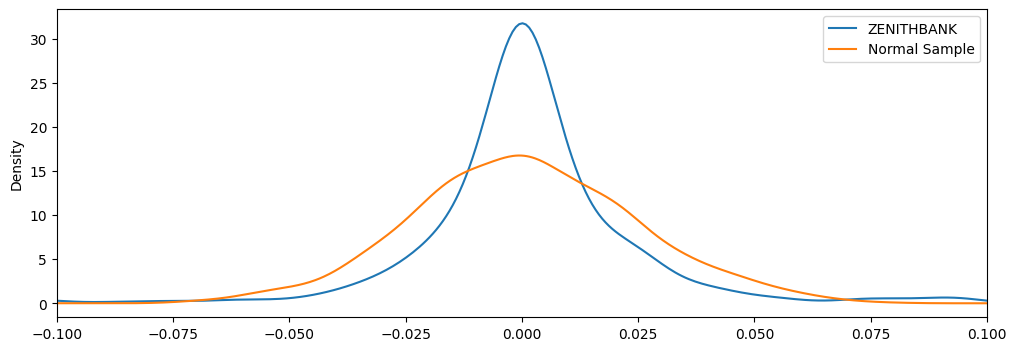

In [50]:
# Sampling from normal distribution
np.random.seed(222)
normal_dist = stats.norm.rvs(size=len(df_return['ZENITHBANK'] ), loc = df_return['ZENITHBANK'].mean(), scale = df_return['ZENITHBANK'].std())

# Creating an additional column in df in order to use the KDE plot functionality of pandas
df_return['Normal Sample'] = normal_dist

# Plotting the KDE plots
df_return[['ZENITHBANK', 'Normal Sample']].plot(kind = 'kde', xlim = (-0.1, 0.1), figsize = (12,4));

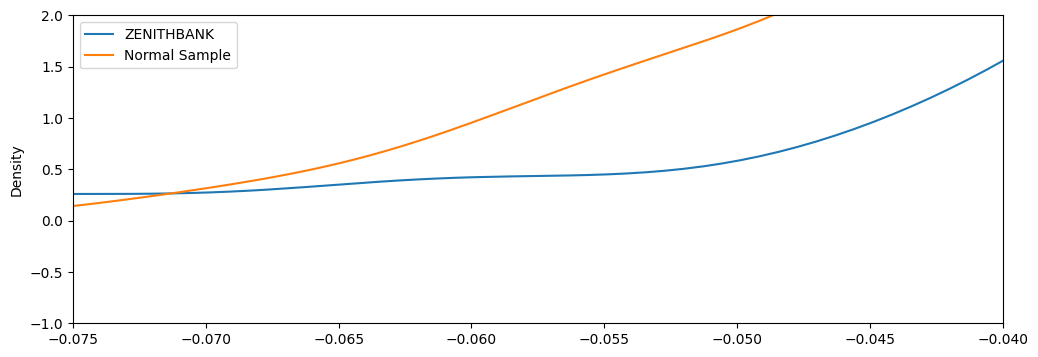

In [51]:
df_return[['ZENITHBANK', 'Normal Sample']].plot(kind = 'kde', figsize = (12,4), xlim = (-0.075, -0.04), ylim = (-1, 2));

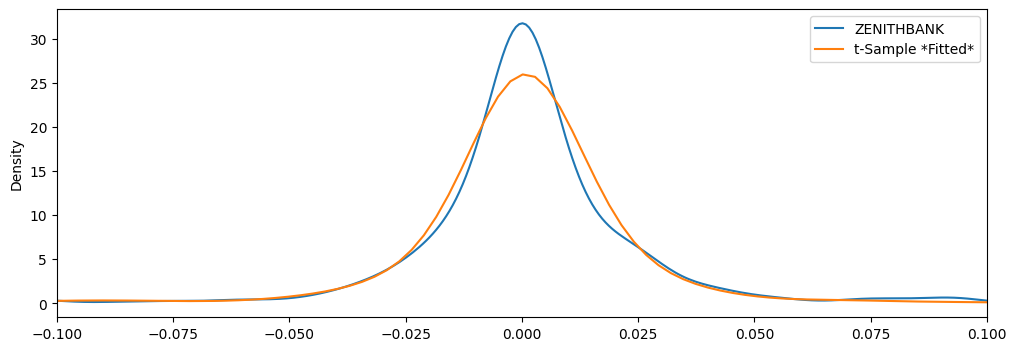

In [52]:
# Fit the t-distribution using MLE
params = stats.t.fit(df_return['ZENITHBANK'])

# We plot the fitted distribution against the kde of the data
df_return['t-Sample *Fitted*'] = stats.t.rvs(*params, size = len(df_return))
df_return[['ZENITHBANK', 't-Sample *Fitted*']].plot(kind = 'kde', figsize = (12,4), xlim = (-0.1, 0.1));

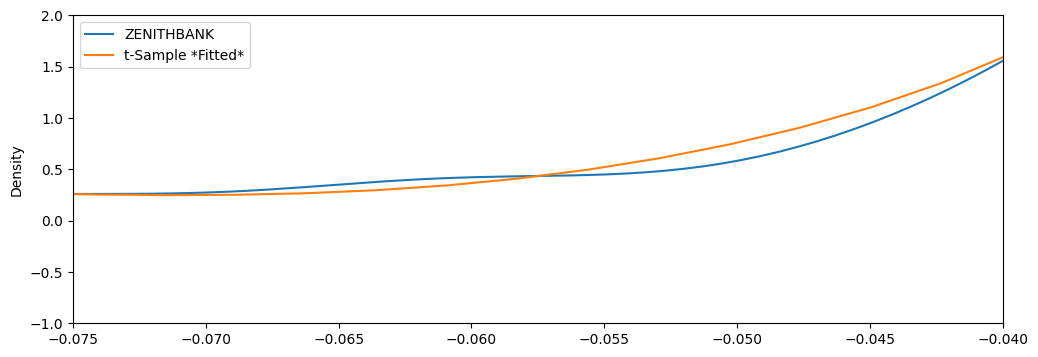

In [53]:
# Plot left tail area
df_return[['ZENITHBANK', 't-Sample *Fitted*']].plot(kind = 'kde', figsize = (12,4), xlim = (-0.075, -0.04), ylim = (-1, 2));

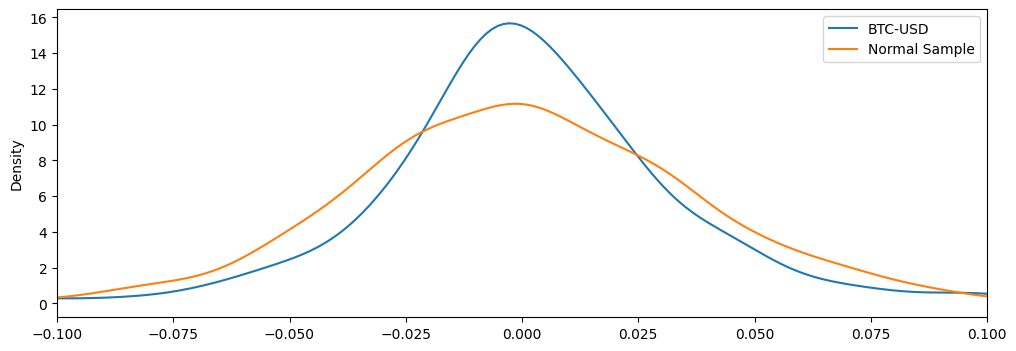

In [54]:
# Sampling from normal distribution
np.random.seed(222)
normal_dist = stats.norm.rvs(size=len(df_return['BTC-USD'] ), loc = df_return['BTC-USD'].mean(), scale = df_return['BTC-USD'].std())

# Creating an additional column in df in order to use the KDE plot functionality of pandas
df_return['Normal Sample'] = normal_dist

# Plotting the KDE plots
df_return[['BTC-USD', 'Normal Sample']].plot(kind = 'kde', xlim = (-0.1, 0.1), figsize = (12,4));

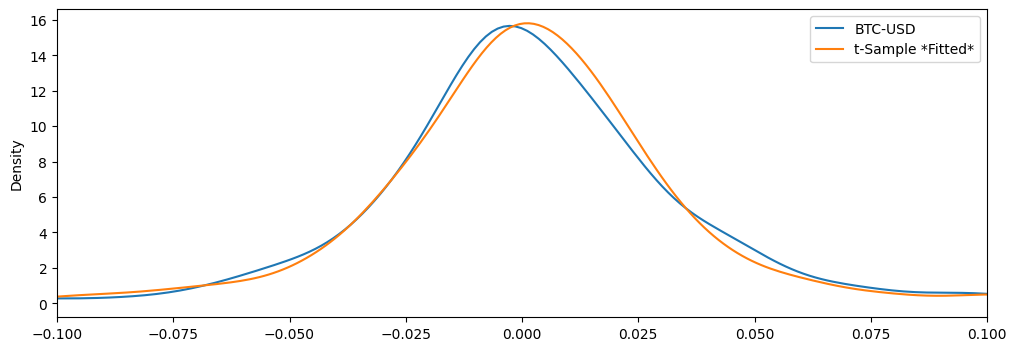

In [55]:
# Fit the t-distribution using MLE
params = stats.t.fit(df_return['BTC-USD'])

# We plot the fitted distribution against the kde of the data
df_return['t-Sample *Fitted*'] = stats.t.rvs(*params, size = len(df_return))
df_return[['BTC-USD', 't-Sample *Fitted*']].plot(kind = 'kde', figsize = (12,4), xlim = (-0.1, 0.1));